# Rule-level diagnostic companion to parent_trend_reversals.ipynb

Pick an index from the source notebook's selected rules. For one stage, compare a rule-bearing eligible FOV with an eligible no-rule FOV, then inspect valid patches, antecedent hits, consequent hits, joint hits, and misses. Reconstructed binary metrics are diagnostic; stored mining FDR remains authoritative.


In [1]:
from pathlib import Path
import sys

ROOT = next(folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (folder / 'result_summary' / 'data_helper.py').exists())
sys.path[:0] = [str(ROOT / 'result_summary'),
                str(ROOT / 'result_summary' / 'differential_rules'),
                str(ROOT / 'result_summary' / 'complex_rules')]
import complex_investigation as ci
import rule_diagnostics as rd
from IPython.display import display

In [2]:
SOURCE = ROOT / 'result_summary' / 'complex_rules' / 'parent_trend_reversals.ipynb'
CONFIG = ci.Config(max_items=4, support=.01,
                   expected_support=.01, confidence=.5, min_cells=20)
INFORMATIVE, MODE = False, 'all'
SPECS = rd.selected_from_notebook(SOURCE)
display(SPECS.rename_axis('index'))

,organ,rule
index,,
0,Duodenum,Epithelial + Plasma -> Fibroblast + Goblet
1,Duodenum,CD4T + Muscle -> CD8T + Macrophage
2,Duodenum,Epithelial + Plasma -> CD8T + Goblet
3,Duodenum,CD4T + Fibroblast + Plasma -> Goblet
4,Duodenum,Epithelial + Plasma_CD38 -> Fibroblast + Goblet
5,Colon,CD4T + Epithelial + Fibroblast -> Goblet
6,Colon,CD4T + Epithelial + Macrophage -> Goblet
7,Colon,CD4T + Epithelial -> Goblet
8,Colon,Fibroblast + Goblet -> CD8T + Epithelial


In [3]:
cells, metadata, rules = ci.load(CONFIG)

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv


{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None, 'avoidance_min_expected_meetings': 30, 'min_label_count': 5, 'min_label_share': None, 'decay_distance': 15.0}, 'steps': {'n_shuffles': 100

In [4]:
def show_selected(index, stage=None, state=None):
    if not 0 <= index < len(SPECS):
        print(f'No selected rule at index {index}; {len(SPECS)} available.')
        return
    spec = SPECS.iloc[index]
    direction = str(spec.get('direction', spec.get('kind', ''))).lower()
    if state is None:
        state = -1 if 'avoid' in direction else (1 if 'attract' in direction else None)
    rd.compare_fields(spec.rule, spec.organ, cells, metadata, rules, CONFIG,
                      stage=stage, state=state, informative=INFORMATIVE, mode=MODE)

Duodenum · Severe: 8/21 eligible FOVs show all passing attraction.
Comparison: rule-bearing GVHD_09_FOV_4 versus eligible no-rule GVHD_19_FOV_3.
A missing stored row does not prove spatial independence: candidate pruning and shuffle FDR matter.


center                     status stored_kind  stored_lift  \
rule FOV    0  Epithelial  passes investigation gate    attracts     2.087124   
            1      Plasma       not stored by mining         NaN          NaN   
no-rule FOV 0  Epithelial       not stored by mining        None          NaN   
            1      Plasma       not stored by mining        None          NaN   

               stored_fdr  valid  antecedent  consequent  joint   Support  \
rule FOV    0    0.006169   2172         322         669    207  0.095304   
            1         NaN   2172          69         669     15  0.006906   
no-rule FOV 0         NaN   2421         168         330     61  0.025196   
            1         NaN   2421          30         330      3  0.001239   

               Confidence      Lift  Expected_support  
rule FOV    0    0.642857  2.087124          0.045663  
            1    0.217391  0.705791          0.009785  
no-rule FOV 0    0.363095  2.663799          0.009459  
            1    0.100000  0.733636          0.001689

The reconstructed metrics alone do not explain why mining omitted this variant; candidate pruning or shuffle significance may matter.


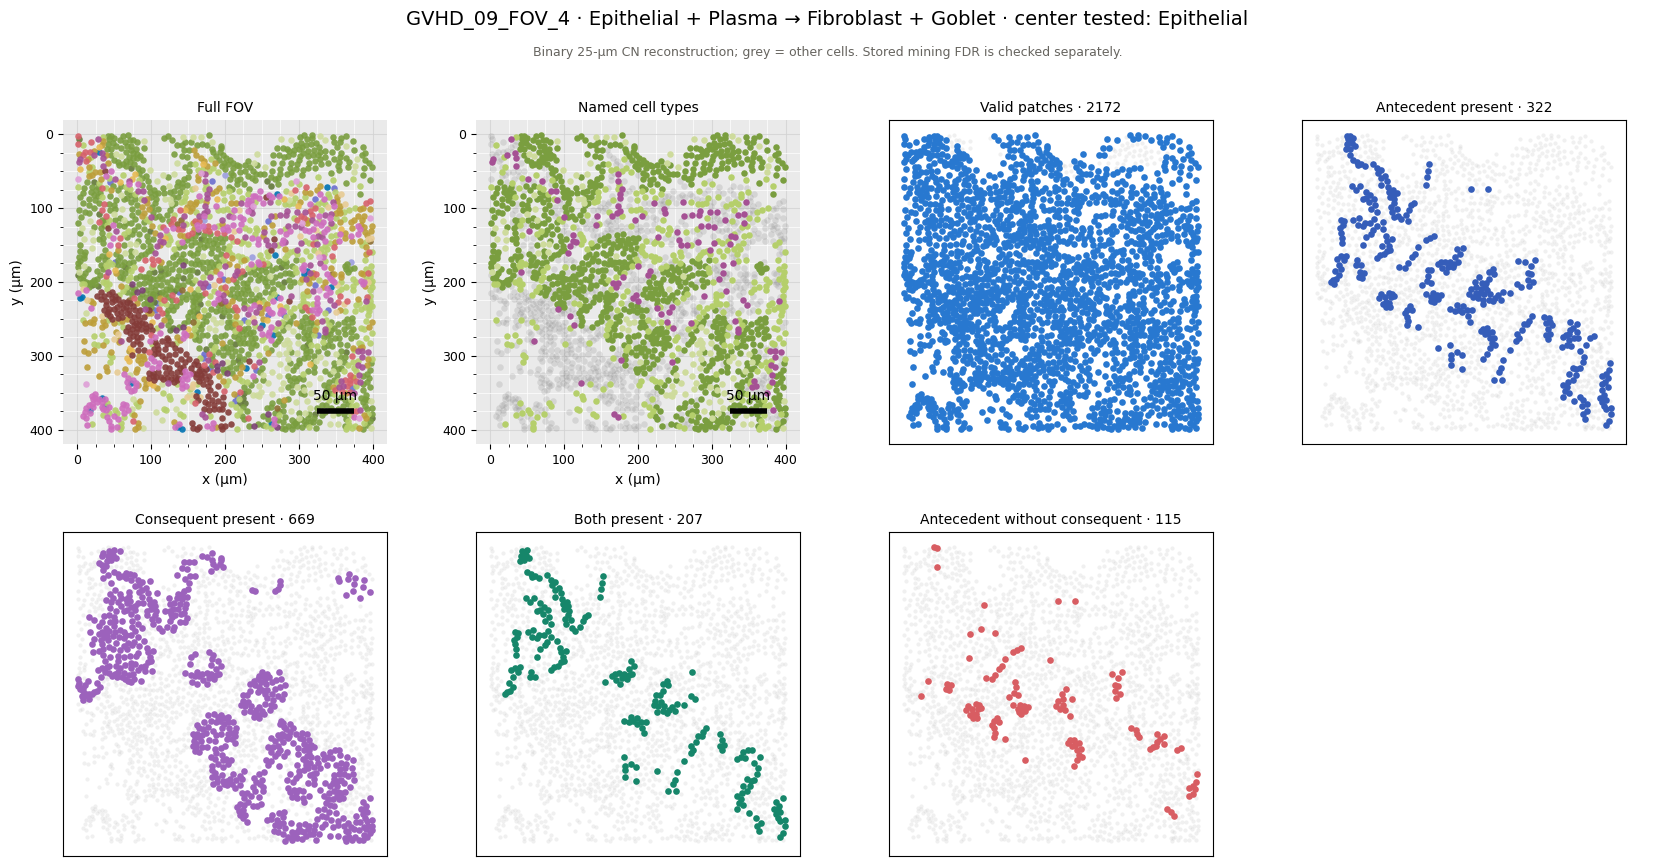

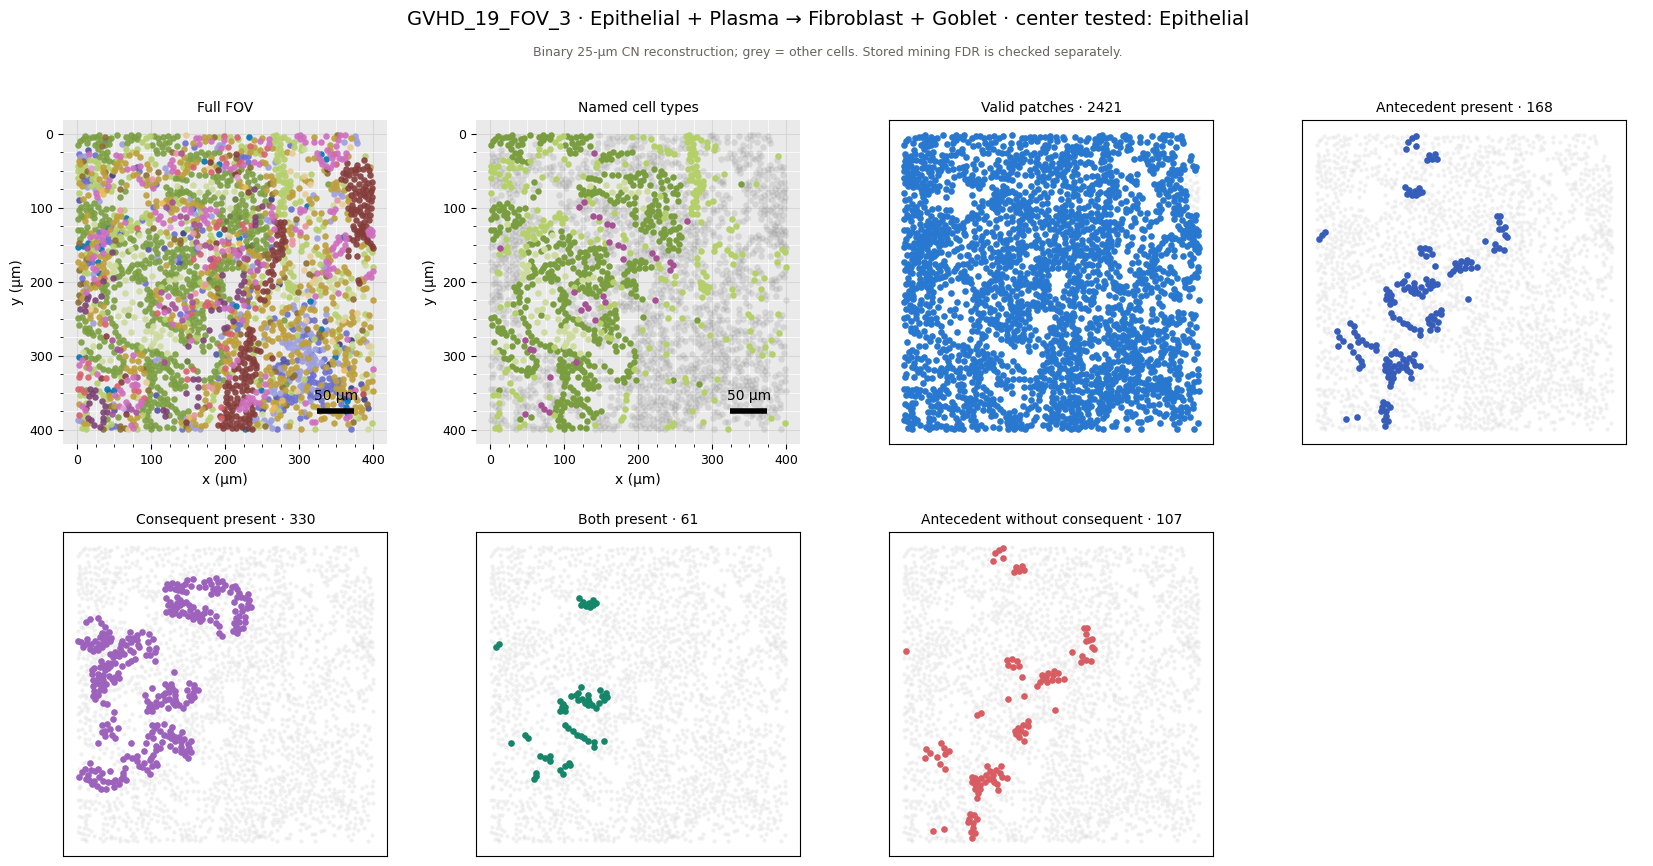

In [5]:
show_selected(0)